<a href="https://colab.research.google.com/github/bhavani2125/My_Projects_Portfolio/blob/main/Copy_of_Netflix_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Step 2: Load the data
netflix_data = pd.read_csv('/content/Netflix_Titles.csv')

In [13]:
sns.set(style="darkgrid")

In [14]:
netflix_data.shape

(8807, 12)

In [15]:
netflix_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [16]:
netflix_data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [18]:
netflix_data_cleaned= netflix_data.dropna()

In [19]:
# Install openpyxl as an Excel engine
!pip install openpyxl

# Save the cleaned data to an Excel file
netflix_data_cleaned.to_excel("netflix_data_cleaned.xlsx", index=False)

In [20]:
# List files to confirm the .csv file is present
!ls -F

netflix_data_cleaned.xlsx  Netflix_Titles.csv  sample_data/


In [21]:
# Load the saved CSV file back into a new DataFrame to verify
netflix_data_reloaded = pd.read_excel('netflix_data_cleaned.xlsx')
print(netflix_data_reloaded.head())

  show_id     type                          title             director  \
0      s8    Movie                        Sankofa         Haile Gerima   
1      s9  TV Show  The Great British Baking Show      Andy Devonshire   
2     s10    Movie                   The Starling       Theodore Melfi   
3     s13    Movie                   Je Suis Karl  Christian Schwochow   
4     s25    Movie                          Jeans           S. Shankar   

                                                cast  \
0  Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
1  Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...   
2  Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...   
3  Luna Wedler, Jannis Niewöhner, Milan Peschel, ...   
4  Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...   

                                             country          date_added  \
0  United States, Ghana, Burkina Faso, United Kin...  September 24, 2021   
1                                     United Kingdom  September 24

In [22]:
netflix_data_cleaned.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [23]:
netflix_data_cleaned.shape

(5332, 12)

In [24]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


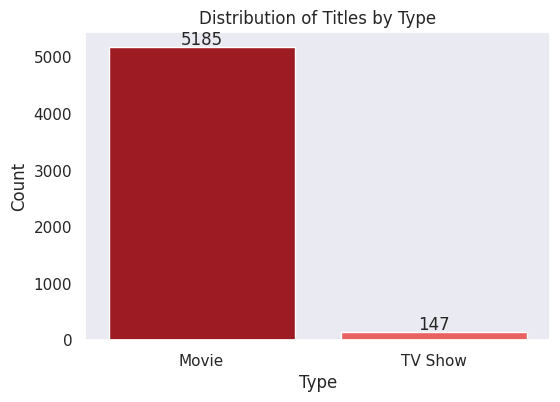

In [25]:
# Step 1: Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Add pandas import

# Define Netflix-like colors for this standalone plot to ensure they are available
dark_red = '#B20710'
bright_red = '#FF4C4C'
# netflix_red = '#E50914' # Not directly used for type differentiation here based on new scheme

# Ensure netflix_data_cleaned is loaded
if 'netflix_data_cleaned' not in locals() or not isinstance(netflix_data_cleaned, pd.DataFrame):
    netflix_data_cleaned = pd.read_csv('netflix_data_cleaned.csv')

#Visual Analysis
#Univariate Analysis
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='type', data=netflix_data_cleaned, hue='type', palette={'Movie': dark_red, 'TV Show': bright_red}, legend=False) # Changed palette
plt.title('Distribution of Titles by Type')
plt.xlabel('Type')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')
ax.grid(False)
plt.show()


Insight: Movies are more prevalent than TV shows on Netflix. This indicates that Netflix has historically focused more on acquiring or producing movies compared to TV shows.

Recommendation: Netflix could explore increasing their series content to balance the distribution.



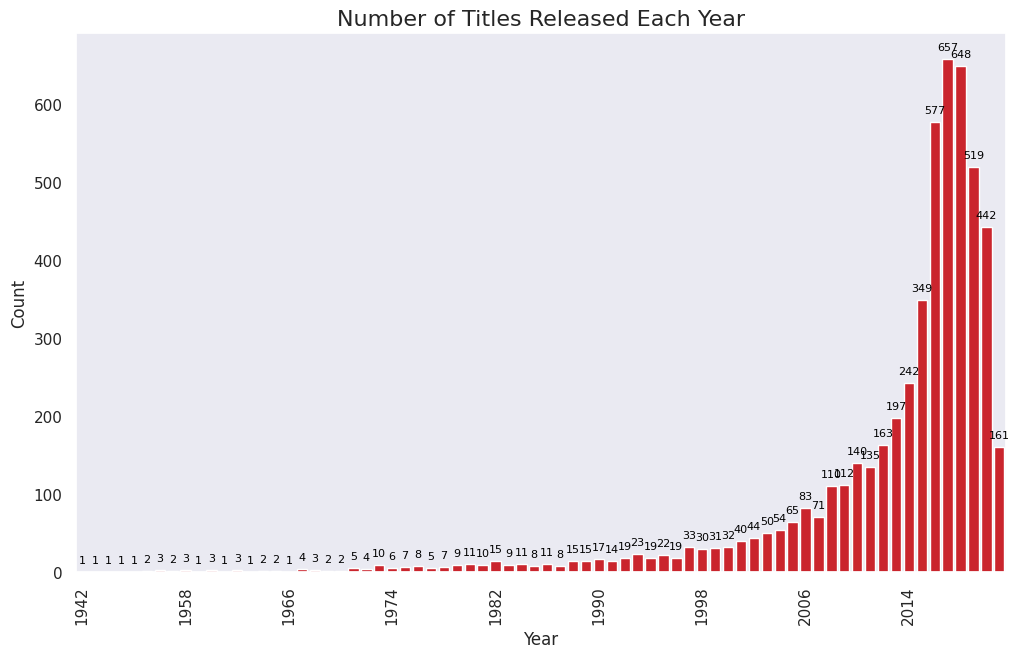

In [26]:
netflix_red = '#E50914'

# Calculate the count of titles per release year
release_year_counts = netflix_data_cleaned['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=release_year_counts.index, y=release_year_counts.values, color=netflix_red)
plt.title('Number of Titles Released Each Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90) # Rotate x-axis labels for better readability

# Reduce the number of x-axis ticks for a smoother scale
import matplotlib.ticker as ticker
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10)) # Adjust nbins as needed

# Add count labels on top of the bars
for p in ax.patches:
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    if y > 0: # Only add label if bar height is greater than 0
        ax.annotate(f'{int(y)}',
                    (x, y),
                    ha='center', va='bottom',
                    fontsize=8,
                    color='black', # Changed to black for better visibility on red bars
                    xytext=(0, 5),
                    textcoords='offset points')
ax.grid(False)
plt.show()

Insight: The number of movies released per year has seen a significant increase, especially in the last decade, indicating a growing trend in movie production and acquisition by Netflix.

  Recommendation: Netflix should continue to invest in new content to maintain and grow its subscriber base.
  

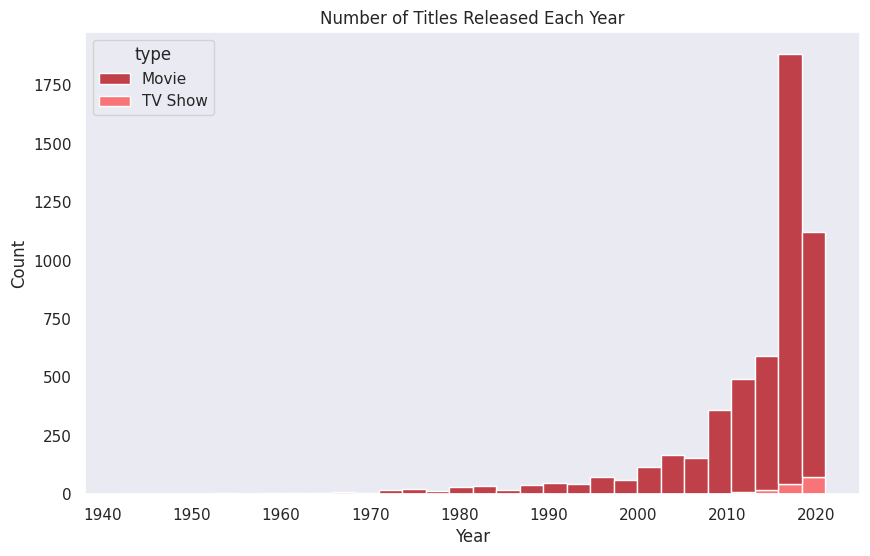

In [27]:
netflix_red = '#E50914'
bright_red = '#FF4C4C'
dark_red = '#B20710'
plt.figure(figsize=(10, 6))
ax = sns.histplot(x='release_year', data=netflix_data_cleaned, bins=30, hue='type', multiple='stack', palette={'Movie': dark_red, 'TV Show': bright_red})
plt.title('Number of Titles Released Each Year')
plt.xlabel('Year')
plt.ylabel('Count')
ax.grid(False)
plt.show()

Insight: TV shows are present but overshadowed Still, that small green slice is quietly growing A hint that series content can spark long-term loyalty

Recommendation: Fuel that momentum Invest in standout mini-series compelling dramas, and addictive reality Transform casual watchers into devoted fans

In [28]:
from collections import Counter

In [29]:
def get_top_elements(column, n=10):
  all_elements = []
  for item in netflix_data_cleaned[column]:
        elements = item.split(', ') #split the string into a list
        all_elements.extend(elements) #add the list of elements to all_elements list
  element_counts = Counter(all_elements)
  top_n = element_counts.most_common(n)
  return top_n

In [30]:
top_directors = get_top_elements('director', 10)

In [31]:
top_directors

[('Jan Suter', 21),
 ('Raúl Campos', 19),
 ('Marcus Raboy', 15),
 ('Jay Karas', 15),
 ('Cathy Garcia-Molina', 13),
 ('Youssef Chahine', 12),
 ('Martin Scorsese', 12),
 ('Jay Chapman', 12),
 ('Steven Spielberg', 11),
 ('Don Michael Paul', 10)]

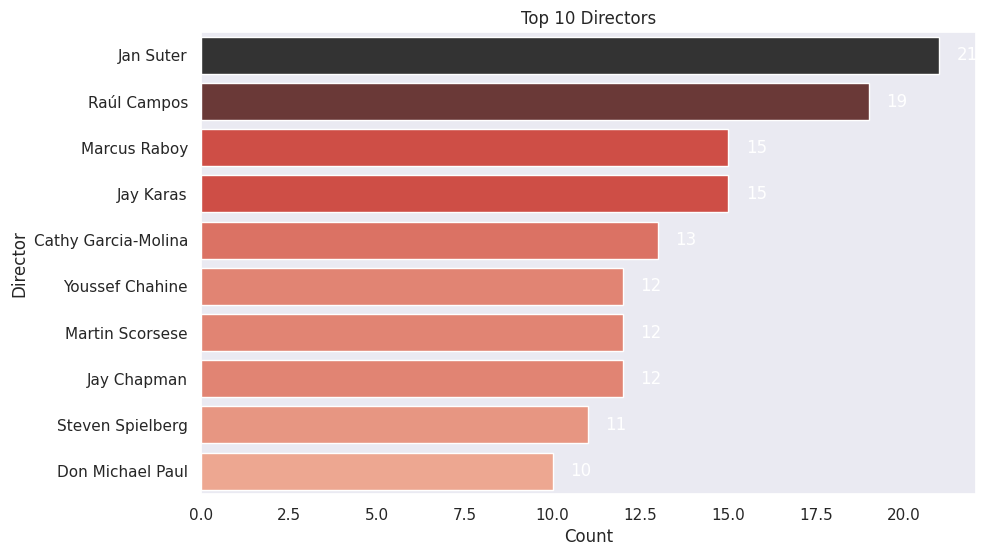

In [32]:
directors, counts = zip(*top_directors)
plt.figure(figsize=(10, 6))
ax=sns.barplot(y=directors, x=counts, hue=counts, palette='Reds_d', legend=False)
plt.title('Top 10 Directors')
plt.xlabel('Count')
plt.ylabel('Director')
# Add labels to the bars
for i, v in enumerate(counts):
    ax.text(v + 0.5, i, str(v), color='white', va='center')
ax.grid(False)
plt.show()


Insight: Certain directors are frequently featured.

Recommendation: Netflix should continue to collaborate with popular actors and directors to attract their fanbase.

In [33]:
# Genre Analysis
print("\nTop 10 genres:")
top_genres = netflix_data_cleaned['listed_in'].value_counts().head(10)
print(top_genres)


Top 10 genres:
listed_in
Dramas, International Movies                        336
Stand-Up Comedy                                     286
Comedies, Dramas, International Movies              257
Dramas, Independent Movies, International Movies    243
Children & Family Movies, Comedies                  179
Dramas, International Movies, Romantic Movies       160
Documentaries                                       156
Comedies, International Movies                      152
Comedies, International Movies, Romantic Movies     143
Dramas                                              133
Name: count, dtype: int64


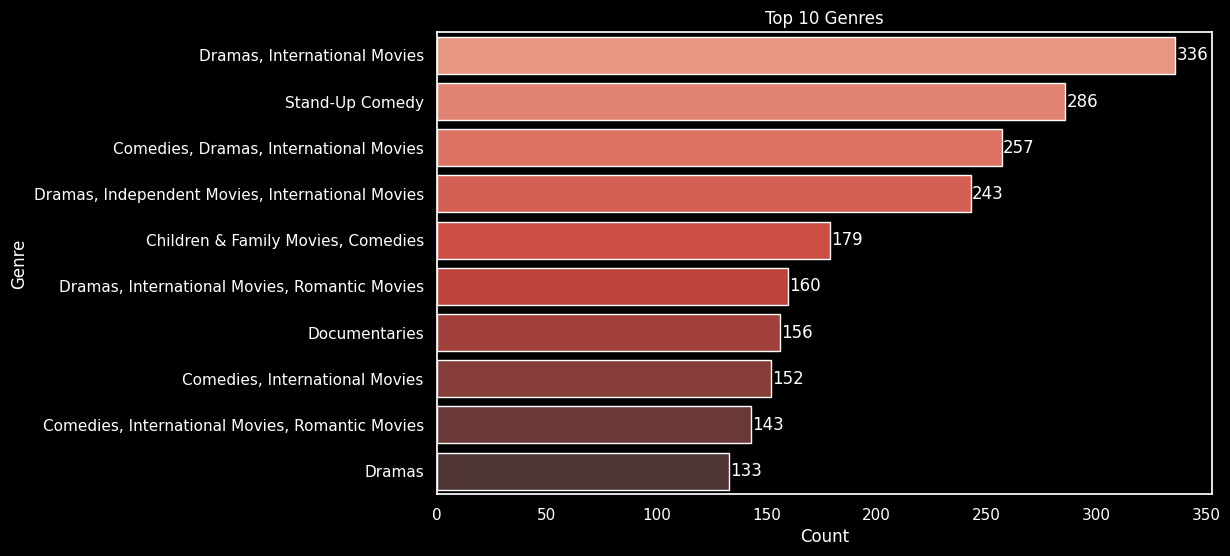

In [ ]:
text_color = 'white'
top_genres = netflix_data_cleaned['listed_in'].value_counts().head(10)
plt.figure(figsize=(10, 6))
ax = sns.barplot(y=top_genres.index, x=top_genres.values, hue=top_genres.index, palette='Reds_d', legend=False)
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
for index, value in enumerate(top_genres.values):
    ax.text(value + 0.5, index, str(value), color=text_color, va='center')
ax.grid(False)
plt.show()


Insight: Drama, Comedy, and International Movies are the most popular genres.

Recommendation: Netflix should invest more in these genres, as they are highly popular among viewers.

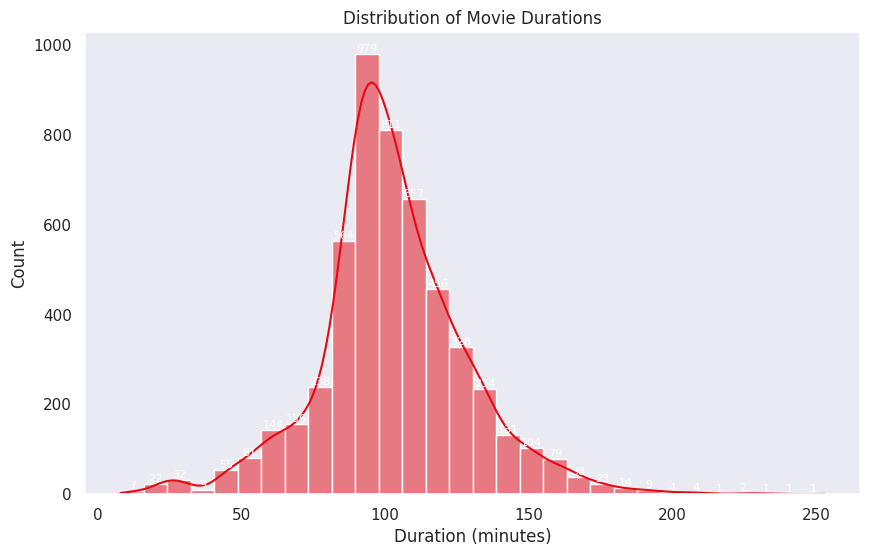

In [34]:
netflix_red = '#E50914'
netflix_movies = netflix_data_cleaned[netflix_data_cleaned['type'] == 'Movie'].copy()
netflix_movies['duration'] = netflix_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(10, 6))
ax = sns.histplot(netflix_movies['duration'], bins=30,kde=True, color=netflix_red)
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    if y > 0:
        ax.text(x, y, f'{int(y)}', ha='center', va='bottom', fontsize=8, color='white')
ax.grid(False)
plt.show()


Insight: Most movies have a duration between 80 and 120 minutes.

Recommendation: Netflix could consider producing more short films and mini-series to cater to viewers with less time.

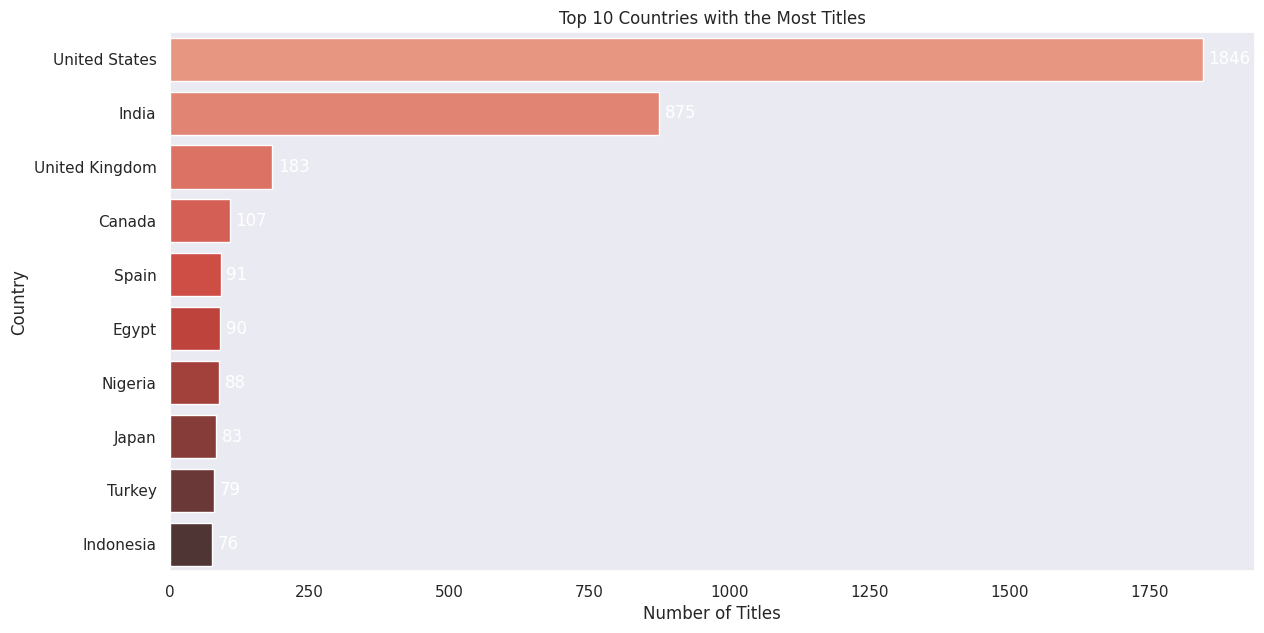

In [35]:
top_countries_content = netflix_data_cleaned['country'].value_counts().head(10)

plt.figure(figsize=(14, 7))
ax = sns.barplot(y=top_countries_content.index, x=top_countries_content.values, hue=top_countries_content.index, palette='Reds_d', legend=False)
for i, v in enumerate(top_countries_content.values):
    ax.text(v + 10, i, str(v), color='white', va='center')
plt.title('Top 10 Countries with the Most Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
ax.grid(False)
plt.show()


Insight: The USA leads in terms of content available on Netflix, followed by other countries. This can help in understanding the distribution of content and guide strategic decisions to expand and diversify the content library for other regions.

Recommendation: Diversify the content library by acquiring more titles from other countries to cater to a global audience.

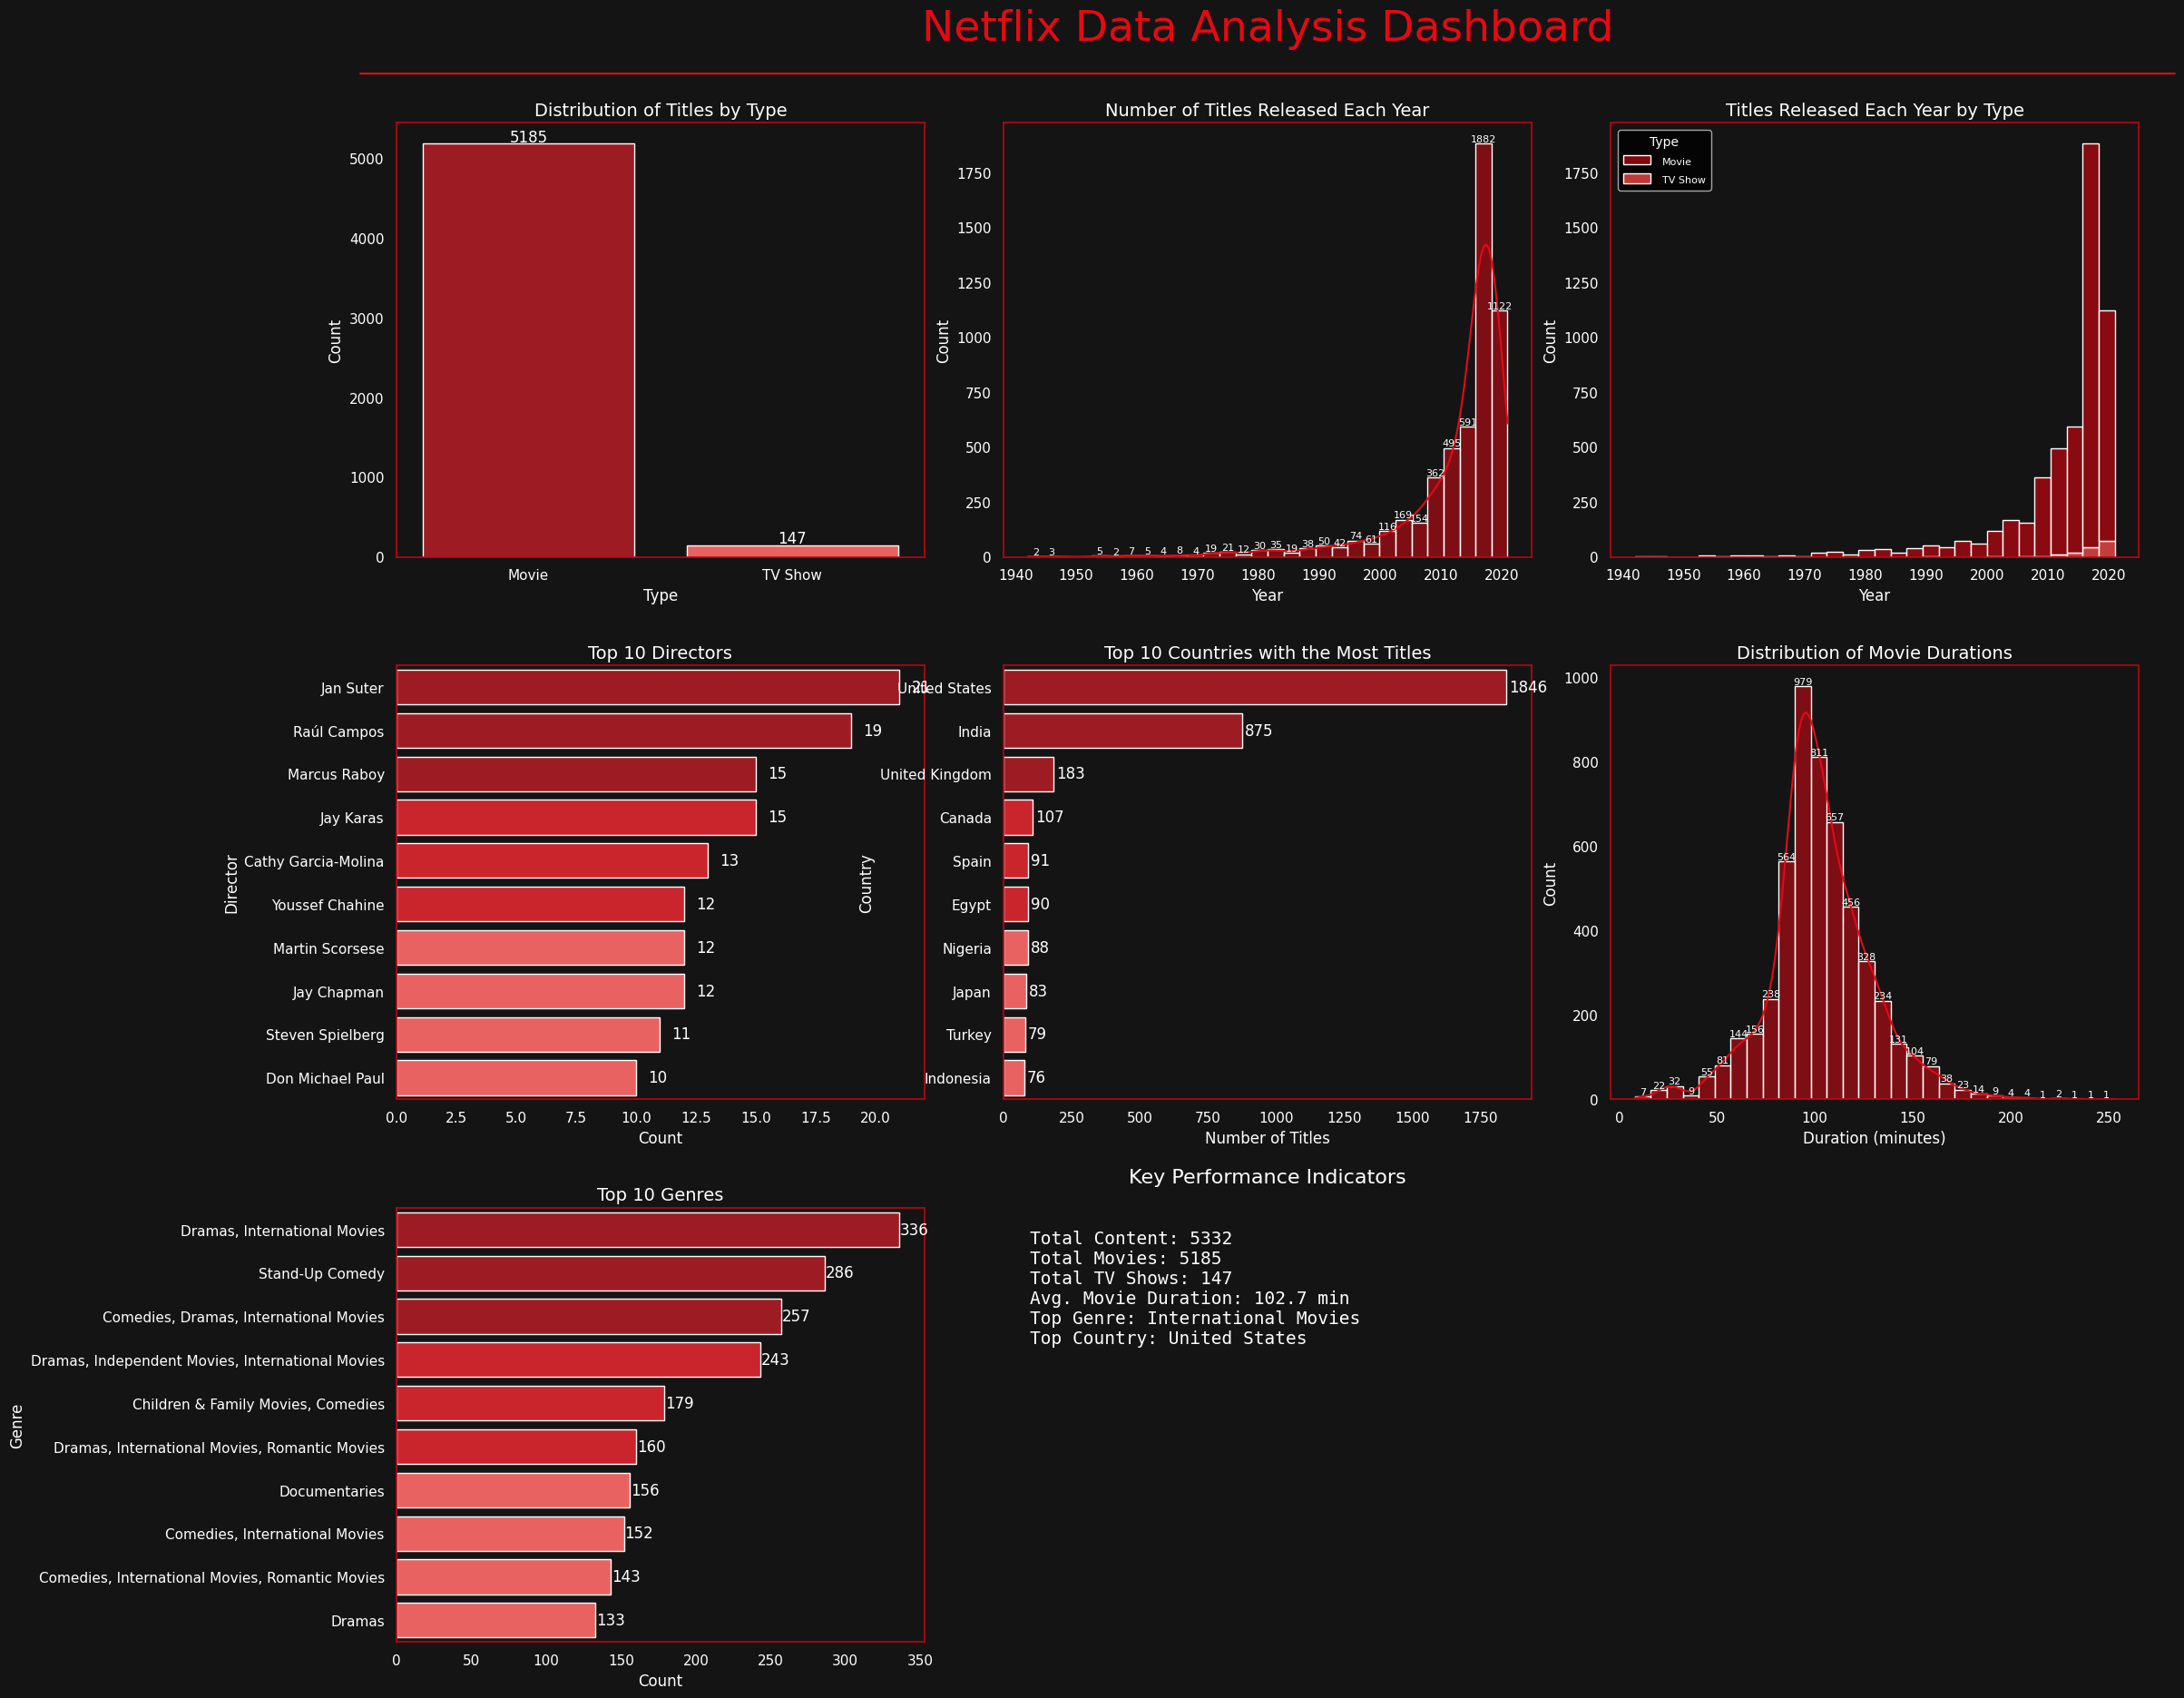

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# Define Netflix-like colors
dark_red = '#B20710'
netflix_red = '#E50914'
bright_red = '#FF4C4C'
netflix_dark = '#141414'
text_color = 'white' # Changed text_color to white for better contrast on dark background

# Ensure netflix_data_cleaned is available (re-run if necessary or use global if confident)
if 'netflix_data_cleaned' not in locals() or not isinstance(netflix_data_cleaned, pd.DataFrame):
    # Load netflix_data_cleaned directly from the saved CSV for robustness
    netflix_data_cleaned = pd.read_csv('netflix_data_cleaned.csv')

# Data preparation for specific plots (re-defined for self-containment)
def get_top_elements(column, n=10):
    all_elements = []
    # Check if column exists to avoid KeyError
    if column in netflix_data_cleaned.columns:
        for item in netflix_data_cleaned[column]:
            # Ensure item is a string before splitting
            if isinstance(item, str):
                elements = item.split(', ')
                all_elements.extend(elements)
    element_counts = Counter(all_elements)
    top_n = element_counts.most_common(n)
    return top_n

top_directors = get_top_elements('director', 10)
directors, director_counts = zip(*top_directors)

top_genres = netflix_data_cleaned['listed_in'].value_counts().head(10)

netflix_movies = netflix_data_cleaned[netflix_data_cleaned['type'] == 'Movie'].copy()
# Handle cases where 'duration' might not be a string or might not contain ' min'
netflix_movies['duration'] = netflix_movies['duration'].astype(str).str.replace(' min', '', regex=False).astype(int)

top_countries_content = netflix_data_cleaned['country'].value_counts().head(10)

# --- KPI Calculations ---
total_content_count = len(netflix_data_cleaned)
total_movies = len(netflix_data_cleaned[netflix_data_cleaned['type'] == 'Movie'])
total_tv_shows = len(netflix_data_cleaned[netflix_data_cleaned['type'] == 'TV Show'])
average_movie_duration = netflix_movies['duration'].mean()
top_genre_overall = get_top_elements('listed_in', 1)[0][0] # Renamed to avoid clash with top_genres Series
top_country_overall = get_top_elements('country', 1)[0][0] # Renamed to avoid clash with top_countries_content Series
# --- End KPI Calculations ---

# Set up the figure and subplots for the dashboard
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18), facecolor=netflix_dark)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Add a suptitle for the entire dashboard
fig.suptitle('Netflix Data Analysis Dashboard', color=netflix_red, fontsize=34, y=1.02) # Adjust y to move title up

# Add a horizontal line to separate the title from the charts
fig.add_artist(plt.Line2D([0, 1], [0.98, 0.98], transform=fig.transFigure, color=netflix_red, linestyle='-')) # Adjusted y-coordinate to 0.94

# Adjust overall figure styling
plt.style.use('dark_background') # Use a dark theme for plots

# Helper function to apply consistent styling to each axis
def apply_axis_style(ax):
    ax.set_facecolor(netflix_dark)
    ax.grid(False)
    ax.tick_params(axis='x', colors=text_color)
    ax.tick_params(axis='y', colors=text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(dark_red) # Set spine color

# Helper function to generate color palette based on value distribution for top N items
def generate_custom_palette(counts, dark_red, netflix_red, bright_red):
    num_items = len(counts)
    colors = []
    # For top 10 items, we'll assign roughly 3 High, 3 Medium, 4 Low to ensure all colors are used.
    # Adjust this logic if the number of items (N) varies significantly or for different distributions.
    if num_items <= 3:
        # Handle cases with very few items, try to distribute colors
        if num_items == 1: colors = [dark_red]
        elif num_items == 2: colors = [dark_red, netflix_red]
        else: colors = [dark_red, netflix_red, bright_red]
    else:
        high_indices_count = max(1, num_items // 3)
        medium_indices_count = max(1, (num_items - high_indices_count) // 2)

        for i in range(num_items):
            if i < high_indices_count:
                colors.append(dark_red) # High values
            elif i < high_indices_count + medium_indices_count:
                colors.append(netflix_red) # Medium values
            else:
                colors.append(bright_red) # Low values
    return colors

# Plot 1: Distribution of Titles by Type (keep existing, as it already shows variation)
ax1 = axes[0]
sns.countplot(x='type', data=netflix_data_cleaned, ax=ax1, hue='type', palette={'Movie': dark_red, 'TV Show': bright_red}, legend=False)
ax1.set_title('Distribution of Titles by Type', color=text_color, fontsize=14)
ax1.set_xlabel('Type', color=text_color, fontsize=12)
ax1.set_ylabel('Count', color=text_color, fontsize=12)
apply_axis_style(ax1)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', color=text_color)

# Plot 2: Number of Titles Released Each Year (univariate histplot)
ax2 = axes[1]
sns.histplot(x='release_year', data=netflix_data_cleaned, bins=30, kde=True, color=netflix_red, ax=ax2)
ax2.set_title('Number of Titles Released Each Year', color=text_color, fontsize=14)
ax2.set_xlabel('Year', color=text_color, fontsize=12)
ax2.set_ylabel('Count', color=text_color, fontsize=12)
apply_axis_style(ax2)
for patch in ax2.patches:
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    if y > 0:
        ax2.text(x, y, f'{int(y)}', ha='center', va='bottom', fontsize=8, color=text_color)

# Plot 3: Number of Titles Released Each Year (bivariate, stacked histplot)
ax3 = axes[2]
sns.histplot(x='release_year', data=netflix_data_cleaned, bins=30, hue='type', multiple='stack', ax=ax3, palette={'Movie': dark_red, 'TV Show': bright_red}, legend=True)
ax3.set_title('Titles Released Each Year by Type', color=text_color, fontsize=14)
ax3.set_xlabel('Year', color=text_color, fontsize=12)
ax3.set_ylabel('Count', color=text_color, fontsize=12)
apply_axis_style(ax3)

# Customize the legend created by sns.histplot
legend = ax3.get_legend()
if legend:
    legend.set_title('Type')
    legend.get_title().set_fontsize('10')
    legend.get_title().set_color(text_color)
    for text in legend.get_texts():
        text.set_fontsize('8')
        text.set_color(text_color)

# Plot 4: Top 10 Directors with custom colors
ax4 = axes[3]
# Create colors based on director_counts
director_palette = generate_custom_palette(list(director_counts), dark_red, netflix_red, bright_red)
sns.barplot(y=list(directors), x=list(director_counts), ax=ax4, hue=list(directors), palette=director_palette, legend=False)
ax4.set_title('Top 10 Directors', color=text_color, fontsize=14)
ax4.set_xlabel('Count', color=text_color, fontsize=12)
ax4.set_ylabel('Director', color=text_color, fontsize=12)
apply_axis_style(ax4)
for i, v in enumerate(director_counts):
    ax4.text(v + 0.5, i, str(v), color=text_color, va='center')

# Plot 5: Top 10 Countries with the Most Titles with custom colors
ax5 = axes[4]
country_palette = generate_custom_palette(top_countries_content.values, dark_red, netflix_red, bright_red)
sns.barplot(y=top_countries_content.index, x=top_countries_content.values, ax=ax5, hue=top_countries_content.index, palette=country_palette, legend=False)
ax5.set_title('Top 10 Countries with the Most Titles', color=text_color, fontsize=14)
ax5.set_xlabel('Number of Titles', color=text_color, fontsize=12)
ax5.set_ylabel('Country', color=text_color, fontsize=12)
apply_axis_style(ax5)
for i, v in enumerate(top_countries_content.values):
    ax5.text(v + 10, i, str(v), color=text_color, va='center')

# Plot 6: Distribution of Movie Durations (histplot, keep existing color)
ax6 = axes[5]
sns.histplot(netflix_movies['duration'], bins=30, kde=True, color=netflix_red, ax=ax6)
ax6.set_title('Distribution of Movie Durations', color=text_color, fontsize=14)
ax6.set_xlabel('Duration (minutes)', color=text_color, fontsize=12)
ax6.set_ylabel('Count', color=text_color, fontsize=12)
apply_axis_style(ax6)
for patch in ax6.patches:
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    if y > 0:
        ax6.text(x, y, f'{int(y)}', ha='center', va='bottom', fontsize=8, color=text_color)

# Plot 7: Top 10 Genres with custom colors
ax7 = axes[6]
genre_palette = generate_custom_palette(top_genres.values, dark_red, netflix_red, bright_red)
sns.barplot(y=top_genres.index, x=top_genres.values, ax=ax7, hue=top_genres.index, palette=genre_palette, legend=False)
ax7.set_title('Top 10 Genres', color=text_color, fontsize=14)
ax7.set_xlabel('Count', color=text_color, fontsize=12)
ax7.set_ylabel('Genre', color=text_color, fontsize=12)
apply_axis_style(ax7)
for index, value in enumerate(top_genres.values):
    ax7.text(value + 0.5, index, str(value), color=text_color, va='center')

# Plot 8: KPIs Summary
ax8 = axes[7]
ax8.set_facecolor(netflix_dark)
ax8.set_title('Key Performance Indicators', color=text_color, fontsize=16, pad=20)
ax8.axis('off') # Hide axes for text display
kpi_text = f"Total Content: {total_content_count}\n"
kpi_text += f"Total Movies: {total_movies}\n"
kpi_text += f"Total TV Shows: {total_tv_shows}\n"
kpi_text += f"Avg. Movie Duration: {average_movie_duration:.1f} min\n"
kpi_text += f"Top Genre: {top_genre_overall}\n"
kpi_text += f"Top Country: {top_country_overall}"

ax8.text(0.05, 0.95, kpi_text, transform=ax8.transAxes, fontsize=14, verticalalignment='top', color=text_color, fontfamily='monospace')

# Hide any unused subplots (axes[8] is unused here)
for i in range(8, len(axes)):
    fig.delaxes(axes[i])

# Replaced plt.tight_layout() with explicit subplots_adjust for more control
fig.subplots_adjust(wspace=0.15, hspace=0.25, top=0.95, bottom=0.02, left=0.02, right=0.98)
plt.show()

## Summary and Recommendations
- Movie Releases Trend: The number of movies released each year has been increasing, especially in the last decade. Recommendation: Continue investing in movie content as it shows strong growth.

- TV Shows vs. Movies: Movies are more prevalent than TV shows. Recommendation: Balance the content library by increasing the production and acquisition of TV shows.

- Best Time to Launch TV Shows: Identifying peak months for TV show releases can help maximize viewership. Recommendation: Launch new TV shows during these peak periods.

- Actors/Directors Analysis: Popular actors and directors can attract more viewers. Recommendation: Collaborate with frequently featured actors and directors to draw their fanbase.

- Focus on TV Shows in Recent Years: There is a shift towards more TV shows. Recommendation: Maintain this focus and continue to diversify the content offerings with new TV shows.

- Content in Different Countries: The USA dominates in content availability. Recommendation: Diversify the content library by acquiring more titles from other countries to cater to a global audience.